# Train the agent with human data

In [ ]:
import sys

sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from agents.agentsCS import AgentCS
from agents.linearQ import TilesQ
from utils.interaction import Episode
from utils.interpreters import gym_interpreter1
from environments.foragers import DiscreteForagersEnv

In [ ]:
data_path = '../data/human/data.csv'
df_human = pd.read_csv(data_path)
df_human.head(1)

,session,power_role,power_forager_id,starting_overhead,map,network_id,time_step,node_id,given_overhead,participant_id,complete,role,investment,forager_id,my_coins,all_coins_simulated,all_coins_real,score,proposed_overhead,normalized_score
0,1,coordinator,NaN,0.05,map3,13,1,13,0.05,4,True,coordinator,0.5,NaN,NaN,60.0,52.0,8.0,0.07,0.081633


In [ ]:
group_columns = ['power_role', 'session', 'network_id', 'time_step']
df_columns = group_columns + ['new_rate', 'next_state', 'wealth', 'inequality', 'reward']

training_data = pd.DataFrame({}, columns=df_columns)

for (power_role, session, network_id, time_step), group in df_human.groupby(group_columns):

    coordinator_score = group[group['role'] == 'coordinator']['score'].to_numpy()
    if len(coordinator_score) == 0:
        continue
    else:
        coordinator_score = coordinator_score[0]
    
    new_rate = group[group['role'] == 'coordinator']['given_overhead'].to_numpy()[0]
    new_rate = round(new_rate, 1)
    next_state = np.array([new_rate, 1.0], dtype=np.float32) 

    wealth = group['score'].sum()
    forager_score = group[group['role'] == 'forager']['score'].to_numpy()
    score_differences = (coordinator_score - forager_score) ** 2 / (wealth + 1e-6)  # Avoid division by zero
    inequality = np.mean(score_differences, axis=0, where=~np.isnan(score_differences))
    reward = wealth - inequality

    training_data = pd.concat([training_data, pd.DataFrame({
        'power_role': [power_role],
        'session': [session],
        'network_id': [network_id],
        'time_step': [time_step],
        'new_rate': [new_rate],
        'next_state': [next_state],
        'wealth': [wealth],
        'inequality': [inequality],
        'reward': [reward],
    })], ignore_index=True)

training_data.sort_values(by=group_columns, inplace=True)
training_data.head(2)

/var/folders/2l/9hd8041n255250thyc7mhkq80000gn/T/ipykernel_96653/3132306502.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  training_data = pd.concat([training_data, pd.DataFrame({
/Users/edgar/virtualenvs/venv-3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/edgar/virtualenvs/venv-3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,power_role,session,network_id,time_step,new_rate,next_state,wealth,inequality,reward
0,coordinator,1,1,1,0.0,"[0.0, 1.0]",53.0,11.943396,41.056604
1,coordinator,1,1,2,0.2,"[0.2, 1.0]",77.0,8.844156,68.155844


In [ ]:
training_data["state"] = (
    training_data
    .groupby(["power_role", "session", "network_id"])["next_state"]
    .shift(1)
)
training_data["done"] = (
    training_data.groupby(["power_role", "session", "network_id"])
    .cumcount(ascending=False)
    .eq(0)
)

training_data.dropna(inplace=True)
training_data.head(10)

,power_role,session,network_id,time_step,new_rate,next_state,wealth,inequality,reward,state,done
1,coordinator,1,1,2,0.2,"[0.2, 1.0]",77.0,8.844156,6.815584e+01,"[0.0, 1.0]",False
2,coordinator,1,1,3,0.4,"[0.4, 1.0]",57.0,9.982456,4.701754e+01,"[0.2, 1.0]",False
3,coordinator,1,1,4,0.5,"[0.5, 1.0]",81.0,1.493827,7.950617e+01,"[0.4, 1.0]",True
5,coordinator,1,3,2,0.6,"[0.6, 1.0]",79.0,9.227848,6.977215e+01,"[0.5, 1.0]",True
9,coordinator,1,7,2,0.0,"[0.0, 1.0]",89.0,7.981273,8.101873e+01,"[0.0, 1.0]",False
10,coordinator,1,7,3,0.4,"[0.4, 1.0]",82.0,1.227642,8.077236e+01,"[0.0, 1.0]",False
11,coordinator,1,7,4,0.3,"[0.3, 1.0]",70.0,2.504762,6.749524e+01,"[0.4, 1.0]",False
12,coordinator,1,7,5,0.2,"[0.2, 1.0]",75.0,2.404444,7.259556e+01,"[0.3, 1.0]",True
14,coordinator,1,9,2,0.8,"[0.8, 1.0]",14.0,4.238095,9.761905e+00,"[0.5, 1.0]",False
15,coordinator,1,9,3,0.8,"[0.8, 1.0]",4.0,3.999999,9.999998e-07,"[0.8, 1.0]",True


In [ ]:
training_data.shape

(76, 11)

In [ ]:
pairs = training_data[['session', 'network_id']].values.tolist()
pairs = [tuple(x) for x in pairs]
len(list(set(pairs)))

28

In [ ]:
num_actions = 11
state_scales = [
    {'min':0.0, 'max':1.0},
    {'min':0.0, 'max':1.0},
]
tiles_parameters = {
    'numDims': 2,
    'numTilings': 8,
    'numTiles': [8, 8],
    'scaleFactors':state_scales,
    'maxSize':4096,
    'alpha':0.1,
    'num_actions': num_actions
}
value_approximator = TilesQ(parameters=tiles_parameters)

In [ ]:
def get_max(state_):
    max_val = -np.inf
    for a in range(11):
        val = value_approximator.predict(state_, a)
        if val > max_val:
            max_val = a
    return max_val

gamma = 0.95
for _ in range(10):
    for idx, row in training_data.iterrows():
        
        state = row['state']
        action = int(row['new_rate']) * 10
        next_state = row['next_state']
        reward = float(row['reward']) 
        update = reward + gamma * get_max(next_state)
        value_approximator.learn(
            state=row['state'],
            action=action,
            update=update,
        )

In [ ]:
num_actions = 11
env = DiscreteForagersEnv(
    initial_rate=0.5,
    initial_wealth=1.0,
    num_foragers=3,
    num_discrete_actions=num_actions
)

agent_parameters = {
    'nA':num_actions,
    'nS':2,
    'gamma':1,
    'epsilon':0,
    'alpha':0.1,
    'Q':value_approximator
}
agent = AgentCS(
    parameters=agent_parameters
)

episode = Episode(
    environment=env,
    env_name="Foragers",
    agent=agent,
    model_name="TilesQ",
    num_rounds=100,
    state_interpreter=gym_interpreter1,
)

list_df = []
for _ in range(100):
    df = episode.run(verbose=0, learn=False)
    df['inequality'] = episode.environment.inequalities
    list_df.append(df)

df = pd.concat(list_df, ignore_index=True)
df["rate"] = df['state'].apply(lambda x: x[0])
df["wealth"] = df['state'].apply(lambda x: x[1])
df["initial_wealth"] = df.loc[0, "state"][1]


IHT full, starting to allow collisions


In [ ]:
training_data['episode'] = training_data.apply(lambda row: f"{row['power_role']}_{row['session']}_{row['network_id']}", axis=1)
training_data['round'] = training_data['time_step']
training_data['rate'] = training_data['new_rate']
training_data['wealth'] = training_data['wealth'].apply(lambda x: np.clip(x / 100, 0, 1))
training_data['source'] = 'RLP'

df['source'] = 'human'

columns = ['episode', 'round', 'rate', 'wealth', 'inequality', 'source']
df = pd.concat([df[columns], training_data[columns]], ignore_index=True)


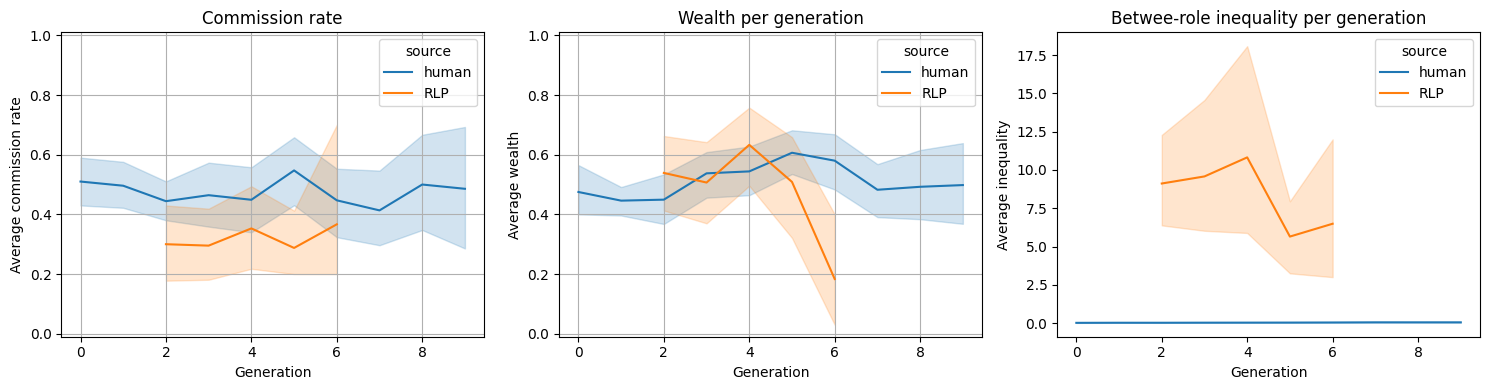

In [ ]:
fig, axes = plt.subplots(
    1, 3, 
    figsize=(15,4), 
    tight_layout=True,
    sharex=True,
    sharey=False,
)
sns.lineplot(
    data=df,
    x='round',
    y='rate',
    hue='source',
    ax=axes[0],
)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Average commission rate")
axes[0].set_title("Commission rate")
sns.lineplot(
    data=df,
    x='round',
    y='wealth',
    hue='source',
    ax=axes[1]
)
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Average wealth")
axes[1].set_title("Wealth per generation")
sns.lineplot(
    data=df,
    x='round',
    y='inequality',
    hue='source',
    ax=axes[2]
)
axes[2].set_xlabel("Generation")
axes[2].set_ylabel("Average inequality")
axes[2].set_title("Betwee-role inequality per generation")

for ax in axes[0:2]:
    ax.grid()
    ax.set_ylim([-.01, 1.01])

In [ ]:
fig.savefig('fast_training.png', dpi=300)